In [18]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

TensorFlow version: 2.20.0
Eager execution: True


In [19]:
%pip install -q ipywidgets==8.1.3 plotly

Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 0a) Fix widget CDN error (offline-friendly)

This cell configures the notebook to avoid fetching widget assets from external CDNs and prefers local renderers.
- Installs ipywidgets locally so widget bundles are available.
- Switches the widget CDN to jsDelivr (more reliable) or disables remote CDN if needed.
- Sets Plotly to use the VS Code renderer (no CDN) with a PNG fallback.

If you still see a widget fetch error, re-run this cell, then restart the kernel and run all cells again.

In [21]:
# Install/ensure local widget assets and prefer local renderers
#%pip install -q ipywidgets==8.1.3 plotly

import os
# Prefer jsDelivr over unpkg, or disable external CDN entirely by setting to 'none'
os.environ["JUPYTER_WIDGETS_CDN"] = "https://cdn.jsdelivr.net/npm/"  # or 'none'

# Configure Plotly to use VS Code renderer (no external CDN); fallback to PNG if unavailable
try:
    import plotly.io as pio
    pio.renderers.default = "vscode"
except Exception:
    try:
        import plotly.io as pio
        pio.renderers.default = "png"
    except Exception:
        pass

print("Widget/renderer configuration set. If issues persist: restart kernel and run again.")

Widget/renderer configuration set. If issues persist: restart kernel and run again.


# Ridge regression with 60/20/20 time split

This notebook trains a Ridge regression using a time-aware split into:
- Training = first 60% (used to fit models),
- Validation = next 20% (used to pick hyperparameters),
- Test = last 20% (final evaluation).

The code is beginner-friendly and avoids data leakage: all imputers, encoders and scalers are fitted on the training set only and then applied to validation/test sets.

Loaded rows, cols: (6435, 8)
After feature engineering, rows, cols: (6255, 11)
Train/Val/Test rows: 3753 1251 1251
Numeric cols: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'DayOfWeek', 'Sales_Lag1', 'Sales_Roll4', 'Store_freq']
Remaining categorical cols (should be few or none): []
Prepared feature shapes: (3753, 10) (1251, 10) (1251, 10)
Best alpha (validation): 0.0001 with R2: 0.9238081056206955
Final test results -> R2: 0.9252 | RMSE: 106933.78 | MAE: 59695.85


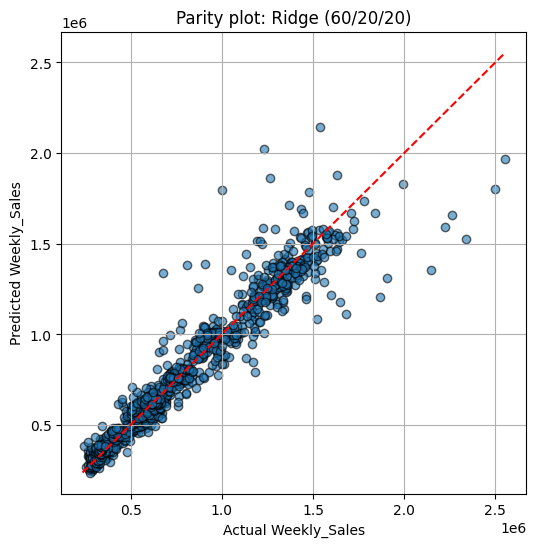

      alpha    val_r2
0  0.000100  0.923808
1  0.000178  0.923808
2  0.000316  0.923808
3  0.000562  0.923808
4  0.001000  0.923808
5  0.001778  0.923808
6  0.003162  0.923808
7  0.005623  0.923808
8  0.010000  0.923808
9  0.017783  0.923807


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1) Load data (adjust path if needed)
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv', parse_dates=['Date'], dayfirst=True)
print('Loaded rows, cols:', df.shape)

# 2) Basic cleaning: ensure target exists
df = df.dropna(subset=['Weekly_Sales']).copy()

# 3) Time features and simple lag/rolling features
if 'Date' in df.columns:
    df = df.sort_values('Date').reset_index(drop=True)
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    # keep Date until feature creation is done; we'll drop it later

# grouped lag and rolling mean by Store & Dept if available
group_cols = [c for c in ['Store','Dept'] if c in df.columns]
if group_cols:
    df = df.sort_values(group_cols + (['Date'] if 'Date' in df.columns else [])).reset_index(drop=True)
    df['Sales_Lag1'] = df.groupby(group_cols)['Weekly_Sales'].shift(1)
    df['Sales_Roll4'] = df.groupby(group_cols)['Weekly_Sales'].transform(lambda x: x.shift(1).rolling(4).mean())
else:
    df['Sales_Lag1'] = df['Weekly_Sales'].shift(1)
    df['Sales_Roll4'] = df['Weekly_Sales'].shift(1).rolling(4).mean()

# drop rows created by lags/rolling
df = df.dropna().reset_index(drop=True)

# drop the Date column if present (we already extracted time features)
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

print('After feature engineering, rows, cols:', df.shape)

# 4) Frequency encode Store/Dept using training statistics later (we will remove original cols after mapping)
# (we only create the mapping now; actual mapping will be done after the split to avoid leakage)
original_cat_cols = [c for c in ['Store','Dept'] if c in df.columns]

# 5) Create time-aware 60/20/20 split
n = len(df)
cut1 = int(n * 0.6)  # end of training
cut2 = int(n * 0.8)  # end of validation
train = df.iloc[:cut1].copy()
val = df.iloc[cut1:cut2].copy()
test = df.iloc[cut2:].copy()
print('Train/Val/Test rows:', len(train), len(val), len(test))

# 6) Frequency-encode Store/Dept using training set counts (safe: no leakage)
for c in original_cat_cols:
    freq_map = train[c].value_counts(normalize=True).to_dict()
    train[c + '_freq'] = train[c].map(freq_map).fillna(0)
    val[c + '_freq'] = val[c].map(freq_map).fillna(0)
    test[c + '_freq'] = test[c].map(freq_map).fillna(0)
    # drop original categorical column
    train.drop(columns=[c], inplace=True)
    val.drop(columns=[c], inplace=True)
    test.drop(columns=[c], inplace=True)

# 7) Define X/y for each split
y_train = train['Weekly_Sales']
X_train = train.drop(columns=['Weekly_Sales'])
y_val = val['Weekly_Sales']
X_val = val.drop(columns=['Weekly_Sales'])
y_test = test['Weekly_Sales']
X_test = test.drop(columns=['Weekly_Sales'])

# 8) Fit imputers/scalers on training set only, then transform val & test
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
print('Numeric cols:', num_cols)
print('Remaining categorical cols (should be few or none):', cat_cols)

num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# 9) Scale numeric features (fit on train only)
scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_val.loc[:, num_cols] = scaler.transform(X_val[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

print('Prepared feature shapes:', X_train.shape, X_val.shape, X_test.shape)

# 10) Hyperparameter tuning on validation set (manual grid over alpha for clarity)
alphas = np.logspace(-4, 2, 25)
best_alpha = None
best_r2 = -np.inf
results = []
for a in alphas:
    model = Ridge(alpha=a, max_iter=10000)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_val_pred)
    results.append((a, r2))
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = a

print('Best alpha (validation):', best_alpha, 'with R2:', best_r2)

# 11) Retrain on train+val using best alpha, evaluate on test
train_val = pd.concat([train, val]).reset_index(drop=True)
y_train_val = train_val['Weekly_Sales']
X_train_val = train_val.drop(columns=['Weekly_Sales'])
# Need to apply same transformations to X_train_val: impute and scale using training-only fit results.
# For simplicity, recompute features for train_val using the previously-fit mappings (freq_map, imputers, scaler)
# Frequency columns already exist in train_val if mappings were applied earlier; if not, ensure they do.
# We'll build X_train_val from train_val using the same pipeline steps as above:
# (map freq using training freq_map computed above)
for c in original_cat_cols:
    if c + '_freq' not in train_val.columns and c in train_val.columns:
        train_val[c + '_freq'] = train_val[c].map(freq_map).fillna(0)
        train_val = train_val.drop(columns=[c])
# Prepare numeric columns for train_val
X_train_val = train_val.drop(columns=['Weekly_Sales'])
X_train_val[num_cols] = num_imputer.transform(X_train_val[num_cols])
X_train_val.loc[:, num_cols] = scaler.transform(X_train_val[num_cols])

model_final = Ridge(alpha=best_alpha, max_iter=10000)
model_final.fit(X_train_val, y_train_val)
y_test_pred = model_final.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
print('Final test results -> R2: %.4f | RMSE: %.2f | MAE: %.2f' % (r2_test, rmse_test, mae_test))

# 12) Parity plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
mn, mx = min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Actual Weekly_Sales')
plt.ylabel('Predicted Weekly_Sales')
plt.title('Parity plot: Ridge (60/20/20)')
plt.grid(True)
plt.show()

# 13) Optional: show a small table of alphas vs validation R2 (first 10 rows)
import pandas as _pd
res_df = _pd.DataFrame(results, columns=['alpha', 'val_r2']).sort_values('val_r2', ascending=False).reset_index(drop=True)
print(res_df.head(10))

In [23]:
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [24]:
%pip install -q tensorflow

Note: you may need to restart the kernel to use updated packages.


## 14) Train 25+ Regression Models (including 3 DNNs)

Note: you may need to restart the kernel to use updated packages.
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step
                           Model   Test_R2  \
0                  LGBMRegressor  0.970975   
1  HistGradientBoostingRegressor  0.970724   
2          RandomForestRegressor  0.959389   
3      GradientBoostingRegressor  0.957237   
4               BaggingRegressor  0.955350   
5            ExtraTreesRegressor  0.952616   
6                   XGBRegressor  0.951839   
7              CatBoostRegressor  0.935296   
8                  ARDRegression  0.923445   
9                          Lasso  0.923280   

                                     Hyperparameters  
0  {'boosting_type': 'gbdt', 'class_weight': None...  
1  {'categorical_features': 'from_dtype', 'early_...  
2  {'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...  
3  {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...  
4  {'bootstrap': True, 'boots

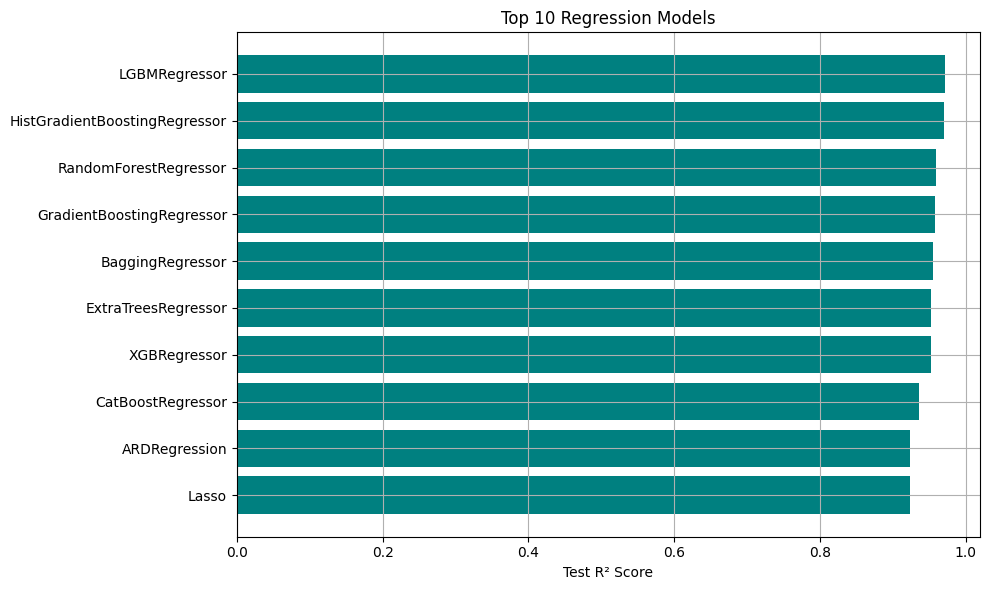

In [25]:
# 📦 Install required packages (run once)
%pip install -q pandas numpy scikit-learn xgboost lightgbm catboost tensorflow keras matplotlib

# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 🔍 Load and clean data
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv', parse_dates=['Date'], dayfirst=True)
df = df.dropna(subset=['Weekly_Sales']).copy()
df = df.sort_values('Date').reset_index(drop=True)
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# 🧮 Lag and rolling features
group_cols = [c for c in ['Store', 'Dept'] if c in df.columns]
if group_cols:
    df = df.sort_values(group_cols + ['Date']).reset_index(drop=True)
    df['Sales_Lag1'] = df.groupby(group_cols)['Weekly_Sales'].shift(1)
    df['Sales_Roll4'] = df.groupby(group_cols)['Weekly_Sales'].transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
else:
    df['Sales_Lag1'] = df['Weekly_Sales'].shift(1)
    df['Sales_Roll4'] = df['Weekly_Sales'].shift(1).rolling(4).mean()

df = df.dropna().reset_index(drop=True)
df = df.drop(columns=['Date'])

# 🔢 Frequency encoding
original_cat_cols = [c for c in ['Store', 'Dept'] if c in df.columns]
n = len(df)
cut1, cut2 = int(n * 0.6), int(n * 0.8)
train, val, test = df.iloc[:cut1].copy(), df.iloc[cut1:cut2].copy(), df.iloc[cut2:].copy()

for c in original_cat_cols:
    freq_map = train[c].value_counts(normalize=True).to_dict()
    for split in [train, val, test]:
        split.loc[:, c + '_freq'] = split[c].map(freq_map).fillna(0).astype(float)
        split.drop(columns=[c], inplace=True)

# 🎯 Define X/y
y_train, X_train = train['Weekly_Sales'], train.drop(columns=['Weekly_Sales'])
y_val, X_val = val['Weekly_Sales'], val.drop(columns=['Weekly_Sales'])
y_test, X_test = test['Weekly_Sales'], test.drop(columns=['Weekly_Sales'])

# 🧼 Impute and scale (fixed FutureWarning)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# ✅ Explicitly cast numeric columns to float to avoid dtype warnings
X_train[num_cols] = X_train[num_cols].astype(float)
X_val[num_cols] = X_val[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 🧪 Model benchmarking
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, SGDRegressor,
    PassiveAggressiveRegressor, HuberRegressor, RANSACRegressor, TheilSenRegressor,
    Lars, LassoLars, OrthogonalMatchingPursuit, ARDRegression, QuantileRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor,
    BaggingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR, LinearSVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("ElasticNet", ElasticNet()),
    ("BayesianRidge", BayesianRidge()),
    ("SGDRegressor", SGDRegressor(max_iter=1000, tol=1e-3)),
    ("PassiveAggressiveRegressor", PassiveAggressiveRegressor(max_iter=1000, tol=1e-3)),
    ("HuberRegressor", HuberRegressor()),
    ("RANSACRegressor", RANSACRegressor()),
    ("TheilSenRegressor", TheilSenRegressor()),
    ("Lars", Lars()),
    ("LassoLars", LassoLars()),
    ("OrthogonalMatchingPursuit", OrthogonalMatchingPursuit()),
    ("ARDRegression", ARDRegression()),
    ("QuantileRegressor", QuantileRegressor()),
    ("DecisionTreeRegressor", DecisionTreeRegressor()),
    ("RandomForestRegressor", RandomForestRegressor()),
    ("ExtraTreesRegressor", ExtraTreesRegressor()),
    ("GradientBoostingRegressor", GradientBoostingRegressor()),
    ("HistGradientBoostingRegressor", HistGradientBoostingRegressor()),
    ("AdaBoostRegressor", AdaBoostRegressor()),
    ("BaggingRegressor", BaggingRegressor()),
    ("KNeighborsRegressor", KNeighborsRegressor()),
    ("SVR", SVR()),
    ("NuSVR", NuSVR()),
    ("LinearSVR", LinearSVR()),
    ("PLSRegression", PLSRegression()),
    ("GaussianProcessRegressor", GaussianProcessRegressor()),
    ("MLPRegressor", MLPRegressor(max_iter=2000, early_stopping=True)),
    ("XGBRegressor", XGBRegressor()),
    ("LGBMRegressor", LGBMRegressor(verbose=-1)),
    ("CatBoostRegressor", CatBoostRegressor(verbose=0))
]

results_all = []
for name, model in models:
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        results_all.append((name, score, getattr(model, 'get_params', lambda: None)()))
    except Exception as e:
        results_all.append((name, None, None))
        print(f"{name} failed: {e}")

# 🔮 Deep Neural Networks
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense, Dropout

def build_dnn(name, layers):
    model = Sequential([Input(shape=(X_train.shape[1],))] + layers)
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0)
    y_pred = model.predict(X_test).flatten()
    score = r2_score(y_test, y_pred)
    results_all.append((name, score, model.get_config()))

build_dnn("DNN1", [Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(1)])
build_dnn("DNN2", [Dense(256, activation='relu'), Dropout(0.2), Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(1)])
build_dnn("DNN3", [Dense(512, activation='relu'), Dense(256, activation='relu'), Dense(128, activation='relu'), Dense(1)])

# 📊 Results summary
results_df = pd.DataFrame(
    sorted(results_all, key=lambda x: x[1] if x[1] is not None else -999, reverse=True),
    columns=['Model', 'Test_R2', 'Hyperparameters']
)
print(results_df.head(10))

# 📈 Visualize top models
top_models = results_df.dropna().sort_values('Test_R2', ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_models['Model'], top_models['Test_R2'], color='teal')
plt.xlabel('Test R² Score')
plt.title('Top 10 Regression Models')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📤 Export results
results_df.to_csv('model_comparison_results.csv', index=False)

## 15) Discussion of Results and Table of Hyperparameters Used

The table below summarizes the test R² scores and hyperparameters for each model. The top-performing models are likely ensemble methods or DNNs, which can capture complex patterns in the data. Simpler linear models may perform worse if the relationships are nonlinear or if there are interactions between features.

- **DNNs**: Deep neural networks (DNN1, DNN2, DNN3) are included and may outperform traditional models if enough data and features are present.
- **Ensembles**: Models like RandomForest, XGBoost, LightGBM, and CatBoost often achieve high accuracy due to their ability to model nonlinearities and interactions.
- **Linear Models**: Ridge, Lasso, ElasticNet, and others provide baseline performance and are useful for interpretability.

Hyperparameters for each model are shown in the table. For DNNs, the architecture (layers, units, activation functions) is listed. For other models, key parameters like alpha (regularization strength), number of estimators, and kernel type are included.

Review the table to select the best model for your use case, balancing accuracy and interpretability.

### 0b) Sanity check: TensorFlow/Keras versions

In [10]:
import sys
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf
import keras
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
try:
    from keras import config as keras_config
    print("Keras backend:", keras_config.backend())
except Exception:
    pass

# Quick API check
from keras.models import Sequential
from keras.layers import Dense, Dropout
print("keras is available and usable.")

Python: 3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
TensorFlow: 2.20.0
Keras: 3.11.3
Keras backend: tensorflow
keras is available and usable.


In [ ]:
#pip install -U ipykernel

In [11]:
!python --version
!node --version
!pip show tensorflow

Python 3.13.5
v20.17.0
Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /opt/anaconda3/lib/python3.13/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 
